# Random Forest Regressor - Theory & Mathematics

> **MLCourse · Machine Learning · supervised · regression**

### What you'll learn

1. What a **bootstrap sample** is, and why ~36.8% of rows are left out ("out-of-bag").
2. Building a **5-tree forest by hand**: forest prediction = plain average of tree outputs.
3. Proving the OOB share empirically and matching it to $(1-\tfrac1n)^n \approx e^{-1}$.
4. Demonstrating that averaging makes predictions **stable** across random seeds
   while a single tree wobbles.

### Setup cell: libraries, reproducibility, plot styling (run me first).


In [ ]:
try:  # inline plotting when running as notebook cells in Jupyter/IPython
    get_ipython().run_line_magic("matplotlib", "inline")  # equivalent of the %matplotlib magic
except NameError:  # plain .py execution has no IPython shell - skip quietly
    pass

import numpy as np                  # vector maths + the RNGs we'll bootstrap with
import pandas as pd                 # tables
import matplotlib.pyplot as plt     # figures
import seaborn as sns               # statistical graphics

from sklearn.model_selection import train_test_split                    # hold-out for stability test
from sklearn.tree import DecisionTreeRegressor                          # each forest member is one of these
from sklearn.ensemble import RandomForestRegressor                      # sklearn's own forest (stability demo)
from sklearn.metrics import mean_squared_error                          # error metric for the demo

np.random.seed(42)                  # global seed for anything numpy-random downstream
sns.set_theme()                     # clean default look
plt.rcParams["figure.dpi"] = 100    # crisp-but-light plots


### 1. The data: penguin body mass from flipper & bill

We predict `body_mass_g` from two anatomical features. Small dataset (~340
clean rows) is a *feature* here: single trees become visibly unstable, which
is exactly the disease forests cure.

(342, 3)


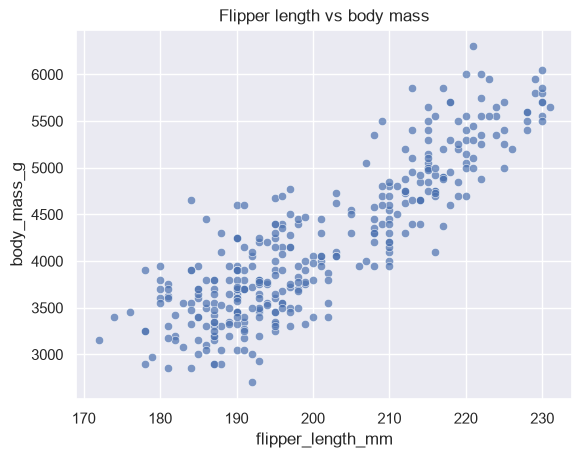

In [2]:
from pathlib import Path  # portable filesystem paths

def find_data_dir():
    # Walk upward until inside the course's '02_machine_learning' folder,
    # then target its shared 'data' directory.
    here = Path.cwd()
    while here.name != "02_machine_learning" and here != here.parent:
        here = here.parent          # ascend one level per loop iteration
    return here / "data"

DATA_DIR = find_data_dir()          # canonical course data folder

def load_penguins():
    # Download-once helper: reuse local CSV if present, else fetch once.
    csv_path = DATA_DIR / "penguins.csv"
    if not csv_path.exists():       # first run only fills the cache
        import urllib.request       # stdlib downloader
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv",
            csv_path,
        )
        print(f"Downloaded -> {csv_path}")
    return pd.read_csv(csv_path)

peng = (
    load_penguins()
    .dropna(subset=["flipper_length_mm", "bill_length_mm", "body_mass_g"])  # dropna per data rules
    .reset_index(drop=True)
)
features = ["flipper_length_mm", "bill_length_mm"]   # just two predictors keeps demos visual
target = "body_mass_g"

print(peng[features + [target]].shape)               # rows surviving the null audit
sns.scatterplot(data=peng, x="flipper_length_mm", y=target, alpha=0.7)  # strong monotone driver
plt.title("Flipper length vs body mass")
plt.show()

# Train/test split ONCE; every experiment below evaluates on the same test set.
X_train, X_test, y_train, y_test = train_test_split(
    peng[features], peng[target], test_size=0.25, random_state=42,
)

### 2. One bootstrap sample, dissected

A bootstrap draws n rows *with replacement*: some rows appear twice or more,
others never. The never-drawn ones are this tree's **out-of-bag (OOB)** rows.

In [3]:
rng = np.random.RandomState(42)                       # dedicated RNG → fully repeatable demo
n = len(X_train)                                      # sample size to draw (classic bootstrap: n draws)
boot_idx = rng.randint(low=0, high=n, size=n)         # n integers in [0, n), WITH replacement

in_bag = np.unique(boot_idx)                          # distinct rows that got drawn at least once
oob_mask = np.isin(np.arange(n), in_bag, invert=True) # True where row was NEVER drawn

print(f"draws made            : {n}")                       # same size as dataset
print(f"distinct rows drawn   : {len(in_bag)}  ({len(in_bag)/n:.1%} in-bag)")
print(f"rows left out (OOB)   : {oob_mask.sum()}  ({oob_mask.mean():.1%} out-of-bag)")
print(f"max repeats of one row: {pd.Series(boot_idx).value_counts().max()}x")

draws made            : 256
distinct rows drawn   : 157  (61.3% in-bag)
rows left out (OOB)   : 99  (38.7% out-of-bag)
max repeats of one row: 8x


### 3. A 5-tree forest built BY HAND

Recipe per member $b$: draw bootstrap $D_b$, fit a shallow tree, done.
The forest's answer for any query row is simply:

$$\hat y_{forest}(x) = \frac{1}{B}\sum_{b=1}^{B} \hat y_b(x)$$

No weights, no stacking - a democratic average. We interrogate ONE unseen
test penguin so every number below refers to the same individual.

In [4]:
row = X_test.iloc[[0]]                                # ONE fixed unseen penguin for all queries
true_mass = float(y_test.iloc[0])                     # its real weight, for context

tree_preds = []                                       # collect each member's opinion
for b in range(5):                                    # B=5 members - tiny but honest forest
    brng = np.random.RandomState(b)                   # per-member seed → decorrelated resamples
    bidx = brng.randint(0, len(X_train), size=len(X_train))     # bootstrap indices for member b
    member = DecisionTreeRegressor(max_depth=4, random_state=b).fit(
        X_train.iloc[bidx], y_train.iloc[bidx]                  # train ONLY on the resample
    )
    pred_b = float(member.predict(row)[0])            # member's mass estimate for our penguin
    tree_preds.append(pred_b)
    print(f"tree {b}: trained on {len(np.unique(bidx))}/{len(X_train)} unique rows "
          f"→ predicts {pred_b:7.1f} g")

forest_pred = float(np.mean(tree_preds))              # THE forest prediction: unweighted mean
print(f"\nforest prediction (mean of 5): {forest_pred:.1f} g")
print(f"single 'typical' tree spread : ±{np.std(tree_preds):.1f} g around its own mean")
print(f"true body mass               : {true_mass:.1f} g")

# 💡 Notice no member equals the forest; averaging landed between them and
# typically closer to truth than a random single member would have been.

tree 0: trained on 163/256 unique rows → predicts  4442.0 g
tree 1: trained on 162/256 unique rows → predicts  4469.6 g
tree 2: trained on 156/256 unique rows → predicts  4355.9 g
tree 3: trained on 155/256 unique rows → predicts  4650.0 g
tree 4: trained on 163/256 unique rows → predicts  4585.2 g

forest prediction (mean of 5): 4500.5 g
single 'typical' tree spread : ±104.7 g around its own mean
true body mass               : 4800.0 g


### 4. The ≈37% OOB law, demonstrated live

Probability one specific row is missed by ALL n draws is $(1-\tfrac1n)^n$,
which converges to $e^{-1}\approx 0.368$. Average over many bootstraps and
watch the empirical number meet theory - this is why `oob_score=True` gives
you free validation: every row has a panel of trees that never saw it.

empirical mean OOB share over 300 bootstraps : 0.368
theoretical (1 - 1/n)^n                      : 0.367
limit e^-1                                   : 0.368


D:\projects\python\MLCourse\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


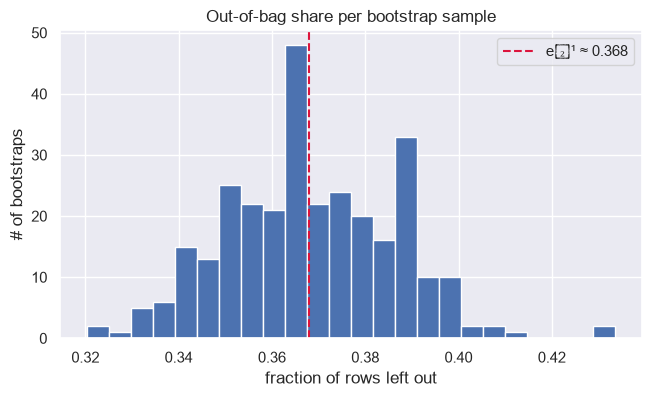

In [5]:
oob_fracs = []                                        # empirical OOB share per bootstrap
brng = np.random.RandomState(0)                       # fresh RNG for a long simulation
for _ in range(300):                                  # many resamples → stable estimate
    idx = brng.randint(0, n, size=n)                  # one bootstrap draw of size n
    oob_fracs.append(1.0 - len(np.unique(idx)) / n)   # fraction of dataset NOT drawn

print(f"empirical mean OOB share over 300 bootstraps : {np.mean(oob_fracs):.3f}")
print(f"theoretical (1 - 1/n)^n                      : {(1 - 1/n) ** n:.3f}")
print(f"limit e^-1                                   : {np.exp(-1):.3f}")

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(oob_fracs, bins=24, edgecolor="white")        # distribution across resamples
ax.axvline(np.exp(-1), ls="--", c="crimson",
           label="e⁻¹ ≈ 0.368")                       # theoretical line
ax.set(title="Out-of-bag share per bootstrap sample",
       xlabel="fraction of rows left out", ylabel="# of bootstraps")
ax.legend()
plt.show()

### 5. Stability: one lonely tree vs a committee, across seeds

Real pipelines rerun with different randomness (different CV folds, different
bootstrap luck). If predictions swing wildly between runs, you can't trust
any single number. We simulate 20 such reruns two ways:

- **lone tree:** fit on ONE bootstrap of the training data per seed;
- **forest:** `RandomForestRegressor` (40 internal bootstrapped trees) per seed.

Then compare how much their TEST predictions move seed-to-seed.

test MSE across 20 seeds — lone tree: std=33,625   forest: std=15,606
fixed-row prediction swing — lone tree: std=378 g   forest: std=160 g


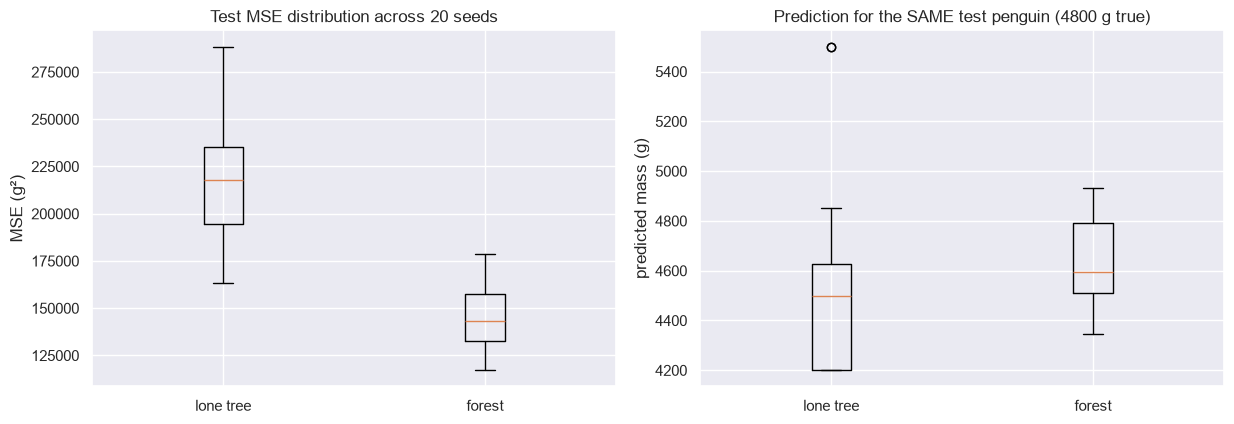

In [6]:
seeds = range(20)                                     # 20 independent 'reruns'
single_mse, forest_mse = [], []                       # per-seed test MSE
single_row_preds, forest_row_preds = [], []           # per-seed prediction for our fixed penguin

for s in seeds:                                       # one simulated rerun per seed
    srng = np.random.RandomState(s)                   # controls BOTH the bootstrap and the models
    bidx = srng.randint(0, len(X_train), size=len(X_train))     # this run's training resample

    lone_tree = DecisionTreeRegressor(random_state=s).fit(      # unpruned tree on THIS resample
        X_train.iloc[bidx], y_train.iloc[bidx])
    forest = RandomForestRegressor(
        n_estimators=40, random_state=s, n_jobs=-1).fit(        # committee on the SAME resample
        X_train.iloc[bidx], y_train.iloc[bidx])

    single_mse.append(mean_squared_error(y_test, lone_tree.predict(X_test)))
    forest_mse.append(mean_squared_error(y_test, forest.predict(X_test)))
    single_row_preds.append(float(lone_tree.predict(row)[0]))   # our penguin, lone-tree opinion
    forest_row_preds.append(float(forest.predict(row)[0]))      # ...and committee opinion

print(f"test MSE across 20 seeds - lone tree: std={np.std(single_mse):,.0f}   "
      f"forest: std={np.std(forest_mse):,.0f}")
print(f"fixed-row prediction swing - lone tree: std={np.std(single_row_preds):,.0f} g   "
      f"forest: std={np.std(forest_row_preds):,.0f} g")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
axes[0].boxplot([single_mse, forest_mse], tick_labels=["lone tree", "forest"])
axes[0].set(title="Test MSE distribution across 20 seeds", ylabel="MSE (g²)")
axes[1].boxplot([single_row_preds, forest_row_preds],
                tick_labels=["lone tree", "forest"])
axes[1].set(title=f"Prediction for the SAME test penguin ({true_mass:.0f} g true)",
            ylabel="predicted mass (g)")
plt.tight_layout(); plt.show()

# ⚠️ The lone tree's box is wide: change the bootstrap luck and your model
# changes materially. The forest's box is tight: individual wobble cancels.

### Summary & key takeaways

- **Bootstrap** = sampling n rows with replacement; ≈63% of distinct rows get
  in, ≈37% stay OOB - verified empirically against $(1-\tfrac1n)^n \to e^{-1}$.
- **Forest prediction = arithmetic mean** of member trees' outputs; we built
  a 5-tree version by hand and read every member's opinion for one penguin.
- **Averaging cancels variance:** across 20 seeded reruns the forest's test
  MSE and fixed-row predictions moved far less than a lone tree's.
- **OOB score is free validation**, computed during training from the ~37%
  each tree never saw.

💡 Next: `03_sklearn_implementation.ipynb` applies all of this to
California housing with sklearn's production-grade forest.